<a href="https://colab.research.google.com/github/iarabertopena/ml-learning-lab/blob/main/stream_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Bibliotecas

In [ ]:
%%writefile requirements.txt
numpy
pandas
scipy
matplotlib
seaborn
capymoa
psutil

In [ ]:
!pip install -r requirements.txt

### Imports

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
import time
import os

from capymoa.classifier import (
HoeffdingAdaptiveTree,
AdaptiveRandomForestClassifier,
SAMkNN,
StreamingGradientBoostedTrees,
StreamingRandomPatches
)

from capymoa.evaluation import (
prequential_evaluation,
ClassificationEvaluator,
ClassificationWindowedEvaluator
)

from capymoa.drift.detectors import ADWIN

from IPython.utils import process
from collections import deque

### Datasets

In [75]:
from capymoa.datasets import Electricity
stream = Electricity()
stream.next_instance().x

array([0.      , 1.      , 0.      , 0.056443, 0.439155, 0.003467,
       0.422915, 0.414912])

In [76]:
from capymoa.datasets import Hyper100k
stream = Hyper100k()
stream.next_instance().x

array([0.39717434, 0.34751803, 0.29405703, 0.50648363, 0.11596709,
       0.77053588, 0.65989271, 0.15674689, 0.37820205, 0.13976268])

In [77]:
from capymoa.datasets import RTG_2abrupt
stream = RTG_2abrupt()
stream.next_instance().x

array([0.73087819, 0.41008081, 0.20771484, 0.33271706, 0.96775591,
       0.00611718, 0.9637048 , 0.93986539, 0.94719492, 0.93708215,
       0.39717434, 0.34751803, 0.29405703, 0.50648363, 0.11596709,
       0.77053588, 0.65989271, 0.15674689, 0.37820205, 0.13976268,
       0.69494798, 0.80522777, 0.00502518, 0.52313516, 0.74398449,
       0.1420227 , 0.4817283 , 0.54455481, 0.57710026, 0.20491355])

In [78]:
from capymoa.datasets import CovtypeTiny
stream = CovtypeTiny()
stream.next_instance().x

array([2.596e+03, 5.100e+01, 3.000e+00, 2.580e+02, 0.000e+00, 5.100e+02,
       2.210e+02, 2.320e+02, 1.480e+02, 6.279e+03, 1.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00])

In [79]:
from capymoa.datasets import Sensor
stream = Sensor()
stream.next_instance().x

array([58.     , 19.7336 , 37.0933 , 71.76   ,  2.69964])

In [80]:
datasets = {
    "Electricity": Electricity,
    "Hyper100k": Hyper100k,
    "RTG_2abrupt": RTG_2abrupt,
    "CovtypeTiny": CovtypeTiny,
    "Sensor": Sensor
}

In [81]:
# visualizando o número de classes:
for dataclass_name, dataclass_class in datasets.items():
    print(f"\n{dataclass_name}")

    stream = dataclass_class()
    _ = stream.next_instance()
    schema = stream.get_schema()

    n_classes = len(schema.get_label_values())
    print("Número de classes:", n_classes)


Electricity
Número de classes: 2

Hyper100k
Número de classes: 2

RTG_2abrupt
Número de classes: 5

CovtypeTiny
Número de classes: 7

Sensor
Número de classes: 57


### Métricas de avaliação

In [ ]:
def get_evaluators(schema):

    return {
        "global": ClassificationEvaluator(),
        "window": ClassificationWindowedEvaluator(window_size=1000),
    }

In [ ]:
def extract_metrics(results):

    extracted = {}

    for name, ev in results.items():
        metrics = ev.get_metrics()

        extracted[name] = {
            "accuracy": metrics.get("accuracy"),
            "kappa": metrics.get("kappa")
        }

    return extracted

In [ ]:
# Accuracy:
# Proporção de instâncias corretamente classificadas.
# Mede o desempenho geral do modelo ao longo do stream (pode ser influenciada por desbalanceamento entre classes).

# Kappa (Cohen’s Kappa):
# Mede o desempenho do modelo em relação ao acaso, considerando a distribuição das classes.
# Mais robusta que a accuracy em cenários desbalanceados.
# Valores:
#   1 → perfeito
#   0 → equivalente ao acaso
#   < 0 → pior que o acaso

# Accuracy (Sliding Window):
# Accuracy calculada apenas nas últimas N instâncias, refletindo o desempenho recente do modelo.
# Útil para detectar concept drift (quanto menor a janela, mais sensível a mudanças rápidas).

# Kappa (Sliding Window):
# Versão do Kappa considerando apenas a janela recente.
# Avalia a qualidade das previsões atuais em relação ao acaso, sendo + informativo que accuracy em streams com drift.

### Definindo os modelos

In [97]:
def get_models(schema):
    return {
        "HAT": HoeffdingAdaptiveTree(schema=schema),
        "ARF": AdaptiveRandomForestClassifier(schema=schema),
        "SAMkNN": SAMkNN(schema=schema),
        "SGBT": StreamingGradientBoostedTrees(schema=schema),
        "SRP": StreamingRandomPatches(schema=schema)
    }

In [98]:
models = {
    "HAT": HoeffdingAdaptiveTree,
    "ARF": AdaptiveRandomForestClassifier,
    "SAMkNN": SAMkNN,
    "SGBT": StreamingGradientBoostedTrees,
    "SRP": StreamingRandomPatches
}

In [99]:
# HAT (Hoeffding Adaptive Tree):
# Árvore de decisão incremental baseada no limite de Hoeffding que aprende a partir de dados em fluxo (sem precisar armazenar tudo).
# Possui mecanismos de adaptação a concept drift, substituindo ramos da árvore quando detecta mudança no comportamento dos dados.

# ARF (Adaptive Random Forest):
# Ensemble de várias Hoeffding Trees, onde cada árvore aprende em subconjuntos diferentes dos dados (bagging online).
# Usa detectores de drift para substituir modelos ruins.

# SAMkNN (Self-Adjusting Memory kNN):
# Versão adaptativa do kNN para data streams, que mantém uma memória de curto e longo prazo.
# Ajusta dinamicamente quais dados usar para prever, lidando bem com concept drift ao esquecer padrões antigos.

# SGBT (Streaming Gradient Boosted Trees):
# Versão online do Gradient Boosting que combina várias árvores sequencialmente corrigindo erros anteriores.
# Aprende de forma incremental em fluxo de dados, podendo capturar relações complexas (mas é mais custoso computacionalmente).

# SRP (Streaming Random Patches):
# Ensemble que combina amostragem de instâncias e atributos, onde cada modelo vê um subconjunto diferente dos dados e features.
# Similar ao Random Forest, mas adaptado para data streams, com bom equilíbrio entre diversidade e desempenho.

### Detecção de drift

In [ ]:
def drift_detection(dataset_class, model_class, schema, max_instances=5000):

  stream = dataset_class()
  model = model_class(schema=schema)

  drift_detector = ADWIN(delta=0.05)

  drift_points = []
  acc_window = []
  corrects = []

  for i in range(max_instances):

    if not stream.has_more_instances():
        break

    instance = stream.next_instance()
    x = instance.x
    y = instance.y_index

    y_pred = model.predict(instance)

    error = int(y_pred != y)
    drift_detector.add_element(error)

    if drift_detector.detected_change():
      drift_points.append(i)

    model.train(instance)

    corrects.append(1 - error)

    if len(corrects) >= 100:
      acc_window.append(np.mean(corrects[-100:]))

  return acc_window, drift_points

### Loop principal

In [ ]:
def run_experiment(dataset_name, dataset_class, max_instances=2000):

    dataset_results = {}

    stream = dataset_class()
    _ = stream.next_instance()
    schema = stream.get_schema()

    print(f"\nDataset: {dataset_name}")

    for name, model in get_models(schema).items():
        print(f"\nRodando modelo: {name}")

        stream = dataset_class()

        # Tempo inicial
        start_time = time.time()

        # Memória inicial
        process = psutil.Process(os.getpid())
        memory_before = process.memory_info().rss / 1024**2  # MB

        # Execução
        res = prequential_evaluation(
            stream=stream,
            learner=model,
            max_instances=max_instances
        )

        # Tempo final
        end_time = time.time()
        execution_time = end_time - start_time

        # Memória final
        memory_after = process.memory_info().rss / 1024**2  # MB
        # memory_usage = memory_after - memory_before
        memory_usage = max(0, memory_after - memory_before)

        # Resultados
        dataset_results[name] = {
            "accuracy": res["cumulative"].accuracy(),
            "kappa": res["cumulative"].kappa(),
            "execution_time": execution_time,
            "memory_usage": memory_usage
        }

        print("Accuracy:", res["cumulative"].accuracy())
        print("Kappa:", res["cumulative"].kappa())
        print("Tempo de execução:", execution_time, "segundos")
        print("Uso de memória:", memory_usage, "MB")

    return dataset_results

In [ ]:
results = run_experiment("CovtypeTiny", CovtypeTiny)

In [ ]:
# Prequential Evaluation:
# Método de avaliação incremental (test-then-train).
# Cada instância é usada primeiro para teste e depois para treino.

### Rodando os 5 datasets

In [ ]:
all_results = {}

for dataset_name, dataset_class in datasets.items():
    #print(f"\n====================")
    #print(f"Dataset: {dataset_name}")
    #print(f"====================")

    all_results[dataset_name] = run_experiment(dataset_name, dataset_class)

#print(all_results)

### Tabela de resultados

In [ ]:
rows = []

for dataset, models in all_results.items():
    for model, metrics_dict in models.items():
        # global_metrics = metrics_dict["ClassificationEvaluator"]
        global_metrics = metrics_dict

        rows.append({
            "Dataset": dataset,
            "Modelo": model,
            "Accuracy": metrics_dict["accuracy"],
            "Kappa": metrics_dict["kappa"],
        })

df = pd.DataFrame(rows)
print(df)

In [ ]:
pivot_acc = df.pivot(index="Modelo", columns="Dataset", values="Accuracy")
pivot_kappa = df.pivot(index="Modelo", columns="Dataset", values="Kappa")

print("=== Accuracy ===")
print(pivot_acc)

print("\n=== Kappa ===")
print(pivot_kappa)

In [ ]:
pivot_acc.T.plot(kind="bar")
plt.title("Comparação de Accuracy entre Modelos e Datasets")
plt.xlabel("Dataset")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
pivot_kappa.T.plot(kind="bar")
plt.title("Comparação de Kappa entre Modelos e Datasets")
plt.xlabel("Dataset")
plt.ylabel("Kappa")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

obs: nota-seque o modelo SAMkNN apresentou desempenho inferior em alguns datasets, especialmente em cenários com mudanças abruptas (como RTG_2abrupt). Como o SAMkNN é um método baseado em memória que depende fortemente da similaridade entre instâncias passadas e atuais, exemplos antigos tornam-se rapidamente obsoletos na presença de concept drift, principalmente abrupto, prejudicando a qualidade das previsões. Além disso, o modelo pode ser sensível ao desbalanceamento de classes, o que impacta negativamente métricas como o Kappa.

In [ ]:
def plot_drift(dataset_class, model_name, model, max_instances=2000):

    stream = dataset_class()

    res = prequential_evaluation(
        stream=stream,
        learner=model,
        max_instances=max_instances,
        window_size=100
    )

    # pega desempenho ao longo do tempo
    windowed_acc = res["windowed"].accuracy()

    plt.figure()
    plt.plot(windowed_acc)

    plt.title(f"Drift - {model_name}")
    plt.xlabel("Instâncias")
    plt.ylabel("Accuracy (janela)")

    plt.show()

In [ ]:
stream = RTG_2abrupt()
schema = stream.get_schema()

model = AdaptiveRandomForestClassifier(schema=schema)

plot_drift(RTG_2abrupt, "ARF", model)

In [ ]:
def compare_models_drift(dataset_class, max_instances=5000):

    stream = dataset_class()
    schema = stream.get_schema()

    plt.figure()

    for name, model in get_models(schema).items():

        stream = dataset_class()

        res = prequential_evaluation(
            stream=stream,
            learner=model,
            max_instances=max_instances,
            window_size=100
        )

        acc = res["windowed"].accuracy()

        plt.plot(acc, label=name)

    plt.title("Desempenho ao longo do tempo (Drift)")
    plt.xlabel("Instâncias")
    plt.ylabel("Accuracy (janela)")
    plt.legend()

    plt.show()

In [ ]:
compare_models_drift(RTG_2abrupt)

### Análise de drift com ADWIN

In [100]:
for dataset_name, dataset_class in datasets.items():

    print(f"\n===== Dataset: {dataset_name} =====")

    stream = dataset_class()
    _ = stream.next_instance()

    schema = stream.get_schema()

    for model_name, model_class in models.items():

        print(f"\nModelo: {model_name}")

        acc, drifts = drift_detection(
            dataset_class,
            model_class,
            schema
        )

        print("Drifts detectados:", drifts[:10])


===== Dataset: Electricity =====

Modelo: HAT
Drifts detectados: [1759, 1791, 1855, 2751, 2783, 4255, 4383]

Modelo: ARF
Drifts detectados: [2143, 2239, 3807, 4383]

Modelo: SAMkNN
Drifts detectados: [2527, 2559]

Modelo: SGBT
Drifts detectados: [255, 1791, 1823, 2143, 2431, 4351]

Modelo: SRP
Drifts detectados: [2143, 2239, 3807]

===== Dataset: Hyper100k =====

Modelo: HAT
Drifts detectados: [1055, 1951]

Modelo: ARF
Drifts detectados: []

Modelo: SAMkNN
Drifts detectados: []

Modelo: SGBT
Drifts detectados: []

Modelo: SRP
Drifts detectados: []

===== Dataset: RTG_2abrupt =====

Modelo: HAT
Drifts detectados: [1471, 2623, 3743, 3775]

Modelo: ARF
Drifts detectados: []

Modelo: SAMkNN
Drifts detectados: []

Modelo: SGBT
Drifts detectados: []

Modelo: SRP
Drifts detectados: []

===== Dataset: CovtypeTiny =====

Modelo: HAT
Drifts detectados: [895, 927]

Modelo: ARF
Drifts detectados: []

Modelo: SAMkNN
Drifts detectados: []

Modelo: SGBT
Drifts detectados: []

Modelo: SRP
Drifts dete

In [103]:
def drift_analysis(
    dataset_class,
    model,
    max_instances=2000,
    window_size=100
):

    stream = dataset_class()

    detector = ADWIN()

    acc_window = []

    sliding_window = deque(maxlen=window_size)

    drift_points = []

    n = 0

    while stream.has_more_instances() and n < max_instances:

        instance = stream.next_instance()

        x = instance.x
        y = instance.y_index

        y_pred = model.predict(instance)

        correct = int(y_pred == y)

        sliding_window.append(correct)

        current_acc = np.mean(sliding_window)

        acc_window.append(current_acc)


        # DETECÇÃO DE DRIFT
        detector.add_element(correct)

        if detector.detected_change():
            drift_points.append(n)

        model.train(instance)

        n += 1


    # PLOT
    plt.figure(figsize=(12,5))

    plt.plot(acc_window, label="Accuracy (janela)")

    for i, drift in enumerate(drift_points):

        plt.axvline(
            x=drift,
            linestyle="--",
            linewidth=1,
            color="red",
            label="Drift detectado" if i == 0 else None
        )

    plt.title("Desempenho ao longo do tempo")

    plt.xlabel("Instâncias")
    plt.ylabel("Accuracy")

    plt.legend()

    plt.tight_layout()
    plt.show()

    print("Drifts detectados:", drift_points)

    return acc_window, drift_points


Dataset: Electricity


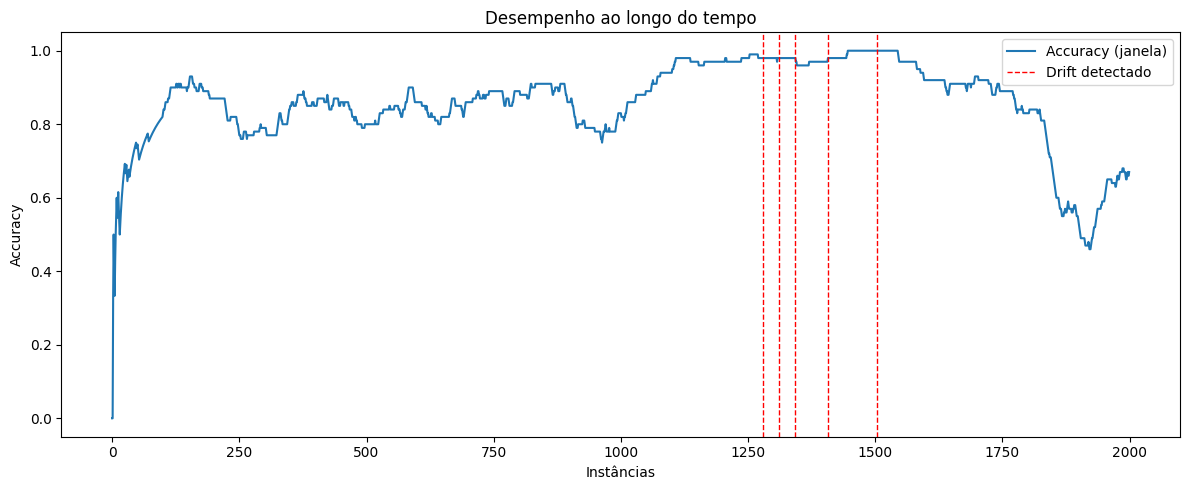

Drifts detectados: [1279, 1311, 1343, 1407, 1503]

Dataset: Hyper100k


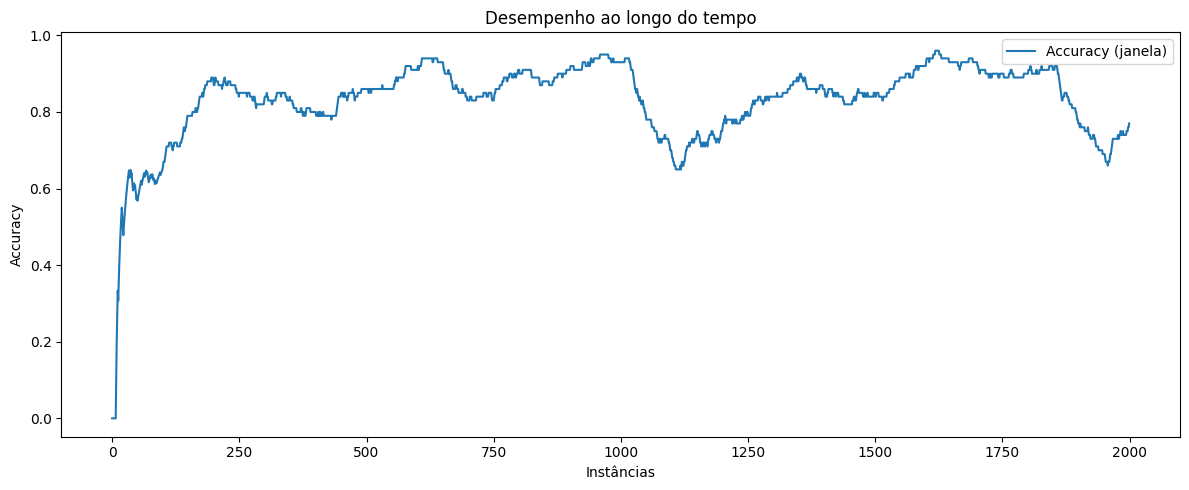

Drifts detectados: []

Dataset: RTG_2abrupt


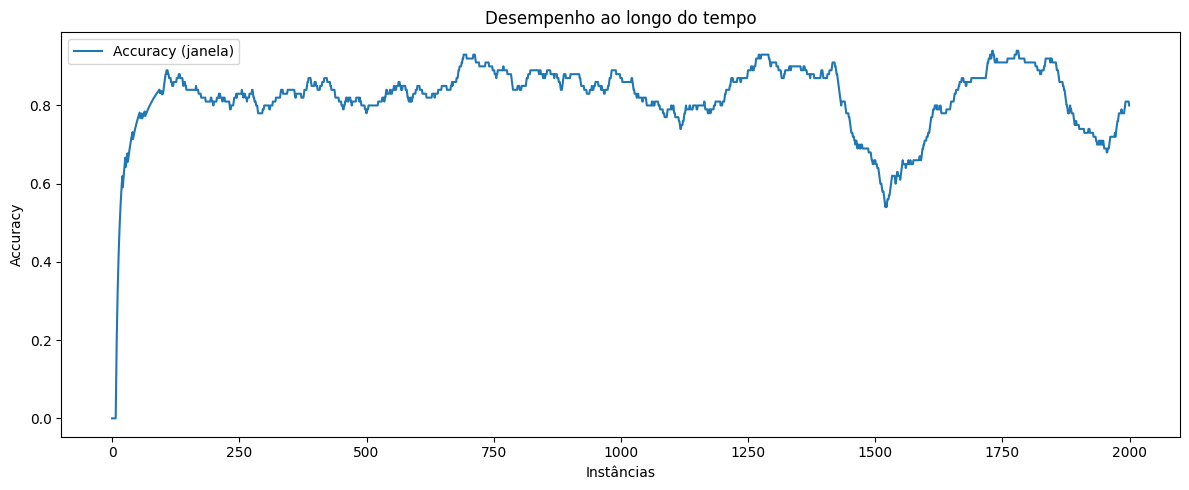

Drifts detectados: []

Dataset: CovtypeTiny


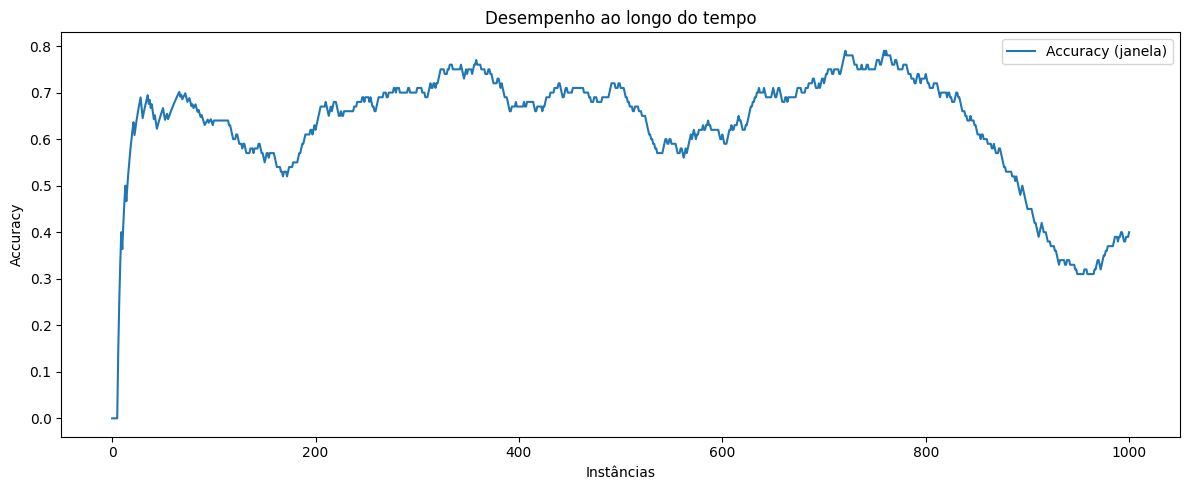

Drifts detectados: []

Dataset: Sensor


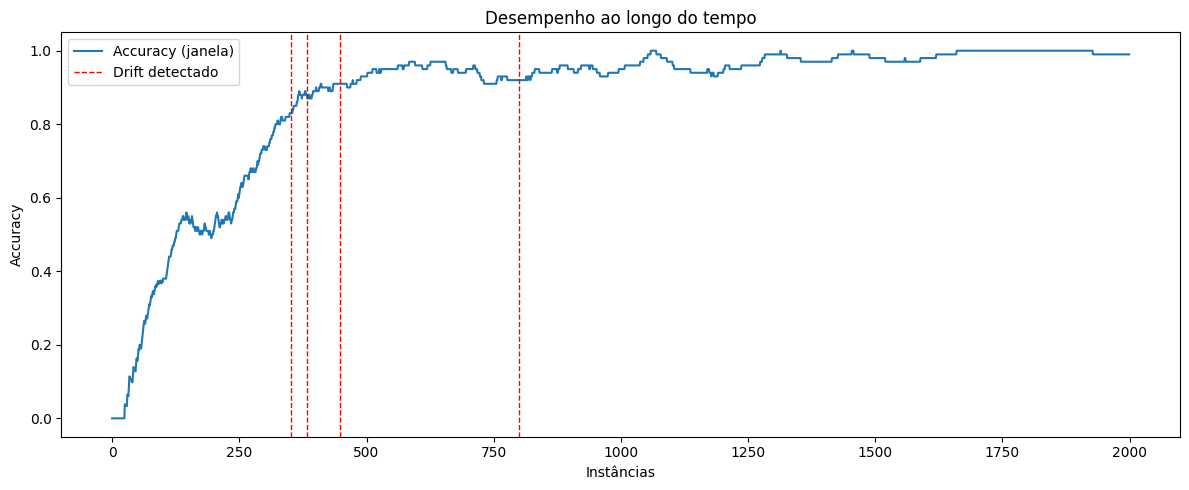

Drifts detectados: [351, 383, 447, 799]


In [104]:
for dataset_name, dataset_class in datasets.items():

    print(f"\nDataset: {dataset_name}")

    stream = dataset_class()
    schema = stream.get_schema()

    model = HoeffdingAdaptiveTree(schema=schema)

    acc_window, drift_points = drift_analysis(
        dataset_class=dataset_class,
        model=model,
        max_instances=2000,
        window_size=100
    )

### Análise de consumo de memória e tempo de execução

In [88]:
rows = []

for dataset, models in all_results.items():
    for model, metrics_dict in models.items():
        # global_metrics = metrics_dict["ClassificationEvaluator"]
        global_metrics = metrics_dict

        rows.append({
            "Dataset": dataset,
            "Modelo": model,
            "Tempo (s)": metrics_dict["execution_time"],
            "Memória (MB)": metrics_dict["memory_usage"]
        })

df = pd.DataFrame(rows)
print(df)

        Dataset  Modelo   Tempo (s)  Memória (MB)
0   Electricity     HAT    0.088198      0.019531
1   Electricity     ARF    7.060097      3.117188
2   Electricity  SAMkNN    0.300009      0.003906
3   Electricity    SGBT    3.783601      0.000000
4   Electricity     SRP    7.905078   1229.632812
5     Hyper100k     HAT    0.062912      0.019531
6     Hyper100k     ARF    7.397102    149.351562
7     Hyper100k  SAMkNN    0.710930      0.019531
8     Hyper100k    SGBT    4.341497      0.000000
9     Hyper100k     SRP    9.018578   1668.945312
10  RTG_2abrupt     HAT    0.134244      0.023438
11  RTG_2abrupt     ARF   13.532326    118.605469
12  RTG_2abrupt  SAMkNN    0.427893      0.250000
13  RTG_2abrupt    SGBT  124.476513   3102.136719
14  RTG_2abrupt     SRP   29.200775      0.000000
15  CovtypeTiny     HAT    0.052191      0.000000
16  CovtypeTiny     ARF    8.807347      2.410156
17  CovtypeTiny  SAMkNN    0.209680      0.000000
18  CovtypeTiny    SGBT   39.247804      0.000000


In [89]:
pivot_time = df.pivot(index = "Modelo", columns = "Dataset", values = "Tempo (s)")
pivot_memory = df.pivot(index = "Modelo", columns = "Dataset", values = "Memória (MB)")

print("=== Tempo (s) ===")
print(pivot_time)

print("\n=== Memória (MB) ===")
print(pivot_memory)

=== Tempo (s) ===
Dataset  CovtypeTiny  Electricity  Hyper100k  RTG_2abrupt      Sensor
Modelo                                                               
ARF         8.807347     7.060097   7.397102    13.532326   11.799893
HAT         0.052191     0.088198   0.062912     0.134244    0.142705
SAMkNN      0.209680     0.300009   0.710930     0.427893    1.298271
SGBT       39.247804     3.783601   4.341497   124.476513  201.693759
SRP         7.835945     7.905078   9.018578    29.200775   12.982320

=== Memória (MB) ===
Dataset  CovtypeTiny  Electricity    Hyper100k  RTG_2abrupt       Sensor
Modelo                                                                  
ARF         2.410156     3.117188   149.351562   118.605469  1215.812500
HAT         0.000000     0.019531     0.019531     0.023438     0.000000
SAMkNN      0.000000     0.003906     0.019531     0.250000     0.339844
SGBT        0.000000     0.000000     0.000000  3102.136719  1721.750000
SRP         0.000000  1229.63281

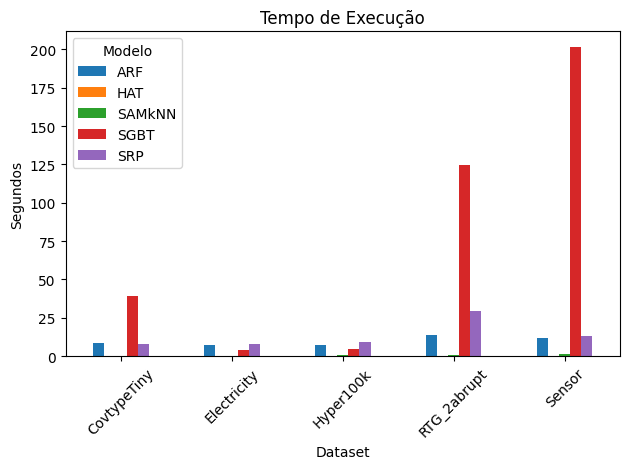

In [90]:
pivot_time = df.pivot(
    index="Dataset",
    columns="Modelo",
    values="Tempo (s)"
)

pivot_time.plot(kind="bar")

plt.title("Tempo de Execução")
plt.ylabel("Segundos")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

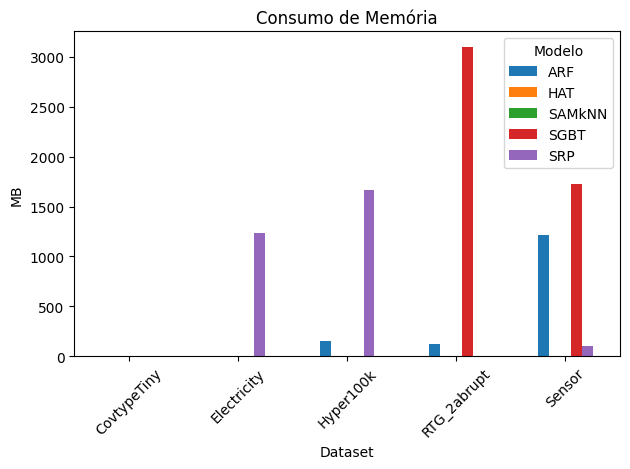

In [91]:
pivot_memory = df.pivot(
    index="Dataset",
    columns="Modelo",
    values="Memória (MB)"
)

pivot_memory.plot(kind="bar")

plt.title("Consumo de Memória")
plt.ylabel("MB")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()